## Imports and Setup

In [2]:
import os
import glob
import numpy as np
import librosa
import soundfile as sf
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings('ignore')

# Paths setup based on Kaggle environment
DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
STEMS_DIR = os.path.join(DATA_ROOT, "genres_stems")
NOISE_DIR = os.path.join(DATA_ROOT, "ESC-50-master", "audio")
MASHUP_DIR = os.path.join(DATA_ROOT, "mashups")

print("Environment setup complete. Directories configured.")

Environment setup complete. Directories configured.


## Metadata Analysis (Duration, Sample Rates, Empty Files)

In [3]:
print("Running Metadata Analysis")

jazz_durations = []
unique_srs = set()
zero_byte_count = 0

# 1. Process Train Stems
stem_files = glob.glob(os.path.join(STEMS_DIR, "*", "*", "*.wav"))
for f in tqdm(stem_files, desc="Stems Metadata"):
    if os.path.getsize(f) == 0:
        zero_byte_count += 1
        continue
    
    # Soundfile is much faster for metadata extraction than librosa.load
    info = sf.info(f)
    unique_srs.add(info.samplerate)
    
    # Check if genre is 'jazz' (Path format: .../genres_stems/jazz/song_name/stem.wav)
    if f.split(os.sep)[-3] == "jazz":
        jazz_durations.append(info.duration)

# 2. Process Noise Data
noise_files = glob.glob(os.path.join(NOISE_DIR, "*.wav"))
for f in tqdm(noise_files, desc="Noise Metadata"):
    if os.path.getsize(f) > 0:
        unique_srs.add(sf.info(f).samplerate)

# 3. Process Mashups (Test Data)
mashup_files = glob.glob(os.path.join(MASHUP_DIR, "*")) 
for f in tqdm(mashup_files, desc="Mashup Metadata"):
    if os.path.getsize(f) > 0:
        try:
            unique_srs.add(sf.info(f).samplerate)
        except:
            # Fallback for MP3s or other formats soundfile might miss
            unique_srs.add(librosa.get_samplerate(f))

print(f"Q1. Mean duration of Jazz stems: {np.mean(jazz_durations):.4f} seconds")
print(f"Q2. Unique sample rates in dataset: {sorted(list(unique_srs))}")
print(f"Q3. Empty (zero-byte) audio files in train: {zero_byte_count}")

Running Metadata Analysis


Stems Metadata:   0%|          | 0/4000 [00:00<?, ?it/s]

Noise Metadata:   0%|          | 0/2000 [00:00<?, ?it/s]

Mashup Metadata:   0%|          | 0/3020 [00:00<?, ?it/s]

Q1. Mean duration of Jazz stems: 30.0330 seconds
Q2. Unique sample rates in dataset: [22050, 44100]
Q3. Empty (zero-byte) audio files in train: 0


## Audio Processing Analysis (Amplitudes, Centroids, Silence)

In [4]:
print("Running Audio Signal Processing")
vocals_peak_db = []
silence_count = 0
genre_centroids = {g: [] for g in os.listdir(STEMS_DIR) if os.path.isdir(os.path.join(STEMS_DIR, g))}

# Only process valid files
valid_stem_files = [f for f in stem_files if os.path.getsize(f) > 0]

for f in tqdm(valid_stem_files, desc="Analyzing Audio Content"):
    genre = f.split(os.sep)[-3]
    filename = os.path.basename(f)
    
    # Load audio (sr=None preserves native sampling rate for exact calculations)
    y, sr = librosa.load(f, sr=None)
    
    if len(y) == 0:
        continue

    # Q7: Check silence in the first 0.5 seconds
    samples_0_5s = int(sr * 0.5)
    segment_to_check = y[:samples_0_5s] if len(y) >= samples_0_5s else y
    if np.max(np.abs(segment_to_check)) < 1e-4:
        silence_count += 1
            
    # Q4: Peak amplitude for vocals
    if "vocals" in filename:
        peak_amp = np.max(np.abs(y))
        db = 20 * np.log10(peak_amp + 1e-9) # 1e-9 prevents log(0)
        vocals_peak_db.append(db)
        
    # Q5 & Q6: Spectral Centroid
    sc = librosa.feature.spectral_centroid(y=y, sr=sr)
    genre_centroids[genre].append(sc.mean())

print("\nProcessing complete. Proceed to Cell 4 for results.")

Running Audio Signal Processing


Analyzing Audio Content:   0%|          | 0/4000 [00:00<?, ?it/s]


Processing complete. Proceed to Cell 4 for results.


## Results Output

In [5]:
# Calculate Q4
mean_vocals_db = np.mean(vocals_peak_db)
print(f"Q4. Average peak amplitude for vocal stems: {mean_vocals_db:.4f} dB")

# Calculate Q5 & Q6
mean_centroids_per_genre = {g: np.mean(vals) for g, vals in genre_centroids.items() if vals}
blues_sc = mean_centroids_per_genre.get('blues', 0)
highest_genre = max(mean_centroids_per_genre, key=mean_centroids_per_genre.get)
highest_sc = mean_centroids_per_genre[highest_genre]

print(f"Q5. Mean spectral centroid for 'blues' genre: {blues_sc:.4f}")
print(f"Q6. Genre with highest mean spectral centroid: '{highest_genre}' (Value: {highest_sc:.4f})")

# Output Q7
print(f"Q7. Stem files containing silence in first 0.5 seconds: {silence_count}")

Final Results
Q4. Average peak amplitude for vocal stems: -12.4949 dB
Q5. Mean spectral centroid for 'blues' genre: 2296.7827
Q6. Genre with highest mean spectral centroid: 'metal' (Value: 2579.3243)
Q7. Stem files containing silence in first 0.5 seconds: 333


## Additional Imports and Feature Extraction Setup

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score

GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz (Using 'other.wav' as per template)
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    
    # Extract features
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    # Handle tempo array vs scalar for different librosa versions
    tempo_val = float(tempo[0]) if isinstance(tempo, np.ndarray) else float(tempo)
    
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    
    return [tempo_val, spec_cent, zcr, rolloff]

print("Setup for Decision Tree feature extraction complete.")

Setup for Decision Tree feature extraction complete.


## Data Preparation & Splitting

In [10]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

print("Extracting features from all train stems... (This will take a moment)")

# Ensure GENRES and STEMS_DIR are defined (re-defining just in case)
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]
# Assuming ROOT is defined from previous cells, otherwise default to Kaggle path
if 'STEMS_DIR' not in locals():
    STEMS_DIR = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems'

data = []
for g in GENRES:
    gp = os.path.join(STEMS_DIR, g)
    if not os.path.exists(gp):
        continue
        
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    
    # Process ALL songs
    for s in tqdm(songs, desc=f"Extracting {g}"): 
        data.append({'path': os.path.join(gp, s), 'genre': g})

# This line caused your error - now fixed by the import above
df = pd.DataFrame(data)

# Stratified Split
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

print(f"\nDataframe created. Train samples: {len(train_df)}, Val samples: {len(val_df)}")

Extracting features from all train stems... (This will take a moment)


Extracting blues:   0%|          | 0/100 [00:00<?, ?it/s]

Extracting classical:   0%|          | 0/100 [00:00<?, ?it/s]

Extracting country:   0%|          | 0/100 [00:00<?, ?it/s]

Extracting disco:   0%|          | 0/100 [00:00<?, ?it/s]

...

Extracting metal:   0%|          | 0/100 [00:00<?, ?it/s]

Extracting pop:   0%|          | 0/100 [00:00<?, ?it/s]

Extracting reggae:   0%|          | 0/100 [00:00<?, ?it/s]

Extracting rock:   0%|          | 0/100 [00:00<?, ?it/s]


Dataframe created. Train samples: 800, Val samples: 200


## Model Training & F1/Classification Report Computation

In [12]:
import os
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

# Ensure these paths match your environment
DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
STEMS_DIR = os.path.join(DATA_ROOT, "genres_stems")
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

print("1. Compiling list of files...")
data = []
for g in GENRES:
    gp = os.path.join(STEMS_DIR, g)
    if os.path.exists(gp):
        songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
        for s in songs: 
            data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
print(f"   Found {len(df)} total songs.")

# Stratified Split
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

print("2. Extracting features... (This takes 2-3 minutes)")
# Apply extract_features to every row
# Note: Ensure 'extract_features' function (from Cell 5) is defined in memory before running this!
X_train = np.array([extract_features(p) for p in tqdm(train_df['path'], desc="Processing Train")])
y_train = train_df['genre']

X_val = np.array([extract_features(p) for p in tqdm(val_df['path'], desc="Processing Val")])
y_val = val_df['genre']

print("\n✅ Done! X_train and y_train are now defined.")
print(f"Training shape: {X_train.shape}")

1. Compiling list of files...
   Found 1000 total songs.
2. Extracting features... (This takes 2-3 minutes)


Processing Train:   0%|          | 0/800 [00:00<?, ?it/s]

Processing Val:   0%|          | 0/200 [00:00<?, ?it/s]


✅ Done! X_train and y_train are now defined.
Training shape: (800, 4)


In [13]:
# Train Decision Tree
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# --- COMPLETING "YOUR CODE HERE" BLOCK 1 ---
y_pred = clf.predict(X_val)

# Compute Metrics
macro_f1 = f1_score(y_val, y_pred, average='macro')
accuracy = accuracy_score(y_val, y_pred)
# Using labels=GENRES ensures the matrix aligns perfectly with our GENRES list
cm = confusion_matrix(y_val, y_pred, labels=GENRES)
cr = classification_report(y_val, y_pred, target_names=GENRES)
cr_dict = classification_report(y_val, y_pred, target_names=GENRES, output_dict=True)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

Model Accuracy: 0.2250
Validation Macro F1 Score: 0.2012

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.00      0.00      0.00        20
   classical       0.00      0.00      0.00        20
     country       0.18      0.35      0.24        20
       disco       0.26      0.25      0.26        20
      hiphop       0.60      0.15      0.24        20
        jazz       0.19      0.20      0.20        20
       metal       0.32      0.60      0.41        20
         pop       0.19      0.30      0.23        20
      reggae       0.44      0.35      0.39        20
        rock       0.05      0.05      0.05        20

    accuracy                           0.23       200
   macro avg       0.22      0.23      0.20       200
weighted avg       0.22      0.23      0.20       200



## Confusion Matrix Visualization & TP/TN/FP/FN Analysis

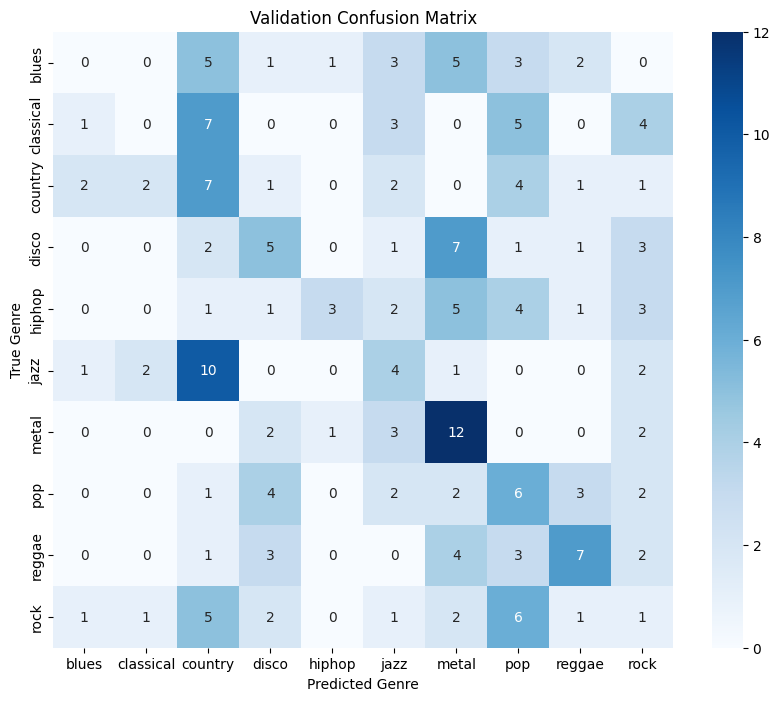


Confusion Matrix Breakdown...
    Genre  TP  FP  FN  TN
    blues   0   5  20 175
classical   0   5  20 175
  country   7  32  13 148
    disco   5  14  15 166
   hiphop   3   2  17 178
     jazz   4  17  16 163
    metal  12  26   8 154
      pop   6  26  14 154
   reggae   7   9  13 171
     rock   1  19  19 161
1. Validation macro F1 score: 0.2012
2. Precision of hiphop: 0.6000
3. Recall of pop: 0.3000
4. Model accuracy: 0.2250
5. Genre with the highest true positives: Metal (Count: 12)
6. Genre with the lowest false negatives: Metal (Count: 8)


In [15]:
# 1. Visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=GENRES, yticklabels=GENRES, cmap='Blues')
plt.xlabel('Predicted Genre')
plt.ylabel('True Genre')
plt.title('Validation Confusion Matrix')
plt.show()

# 2. Compute TP, TN, FP, FN for all genres
tp = np.diag(cm)
fp = np.sum(cm, axis=0) - tp
fn = np.sum(cm, axis=1) - tp
tn = np.sum(cm) - (fp + fn + tp)

metrics_df = pd.DataFrame({
    'Genre': GENRES,
    'TP': tp,
    'FP': fp,
    'FN': fn,
    'TN': tn
})

print("\nConfusion Matrix Breakdown...")
print(metrics_df.to_string(index=False))

# Calculate highest TP and lowest FN
highest_tp_genre = metrics_df.loc[metrics_df['TP'].idxmax(), 'Genre']
lowest_fn_genre = metrics_df.loc[metrics_df['FN'].idxmin(), 'Genre']

print(f"1. Validation macro F1 score: {macro_f1:.4f}")
print(f"2. Precision of hiphop: {cr_dict['hiphop']['precision']:.4f}")
print(f"3. Recall of pop: {cr_dict['pop']['recall']:.4f}")
print(f"4. Model accuracy: {accuracy:.4f}")
print(f"5. Genre with the highest true positives: {highest_tp_genre.capitalize()} (Count: {metrics_df['TP'].max()})")
print(f"6. Genre with the lowest false negatives: {lowest_fn_genre.capitalize()} (Count: {metrics_df['FN'].min()})")